<div style="padding:34px 36px; border-radius:18px; background:linear-gradient(135deg,#123A63 0%,#176B87 58%,#1FA187 100%); color:white; margin-bottom:22px; box-shadow:0 8px 24px rgba(18,58,99,.18);">
  <div style="font-size:13px; letter-spacing:2px; font-weight:700; opacity:.88;">CUADERNO 3 · PREDICCIÓN Y POC</div>
  <h1 style="margin:10px 0 8px 0; font-size:36px; color:white;">Reconocimiento multilabel de instrumentos quirúrgicos</h1>
  <p style="font-size:18px; margin:0; opacity:.94;">Función de predicción, conclusiones y prototipo web</p>
  <div style="margin-top:22px; font-size:15px;"><b>Estudiantes:</b> Madeleine Arévalo, Tatiana Aucapiña y Esteban Tuquiñagui &nbsp;&nbsp;|&nbsp;&nbsp; <b>Año:</b> 2026</div>
</div>

### Propósito del cuaderno

Este cuaderno utiliza el modelo entrenado en el Cuaderno 2 para reconocer uno o varios instrumentos quirúrgicos en imágenes nuevas. Su contenido responde a los siguientes apartados de la práctica:

| Apartado | Desarrollo |
|---|---|
| **1.4** | Función propia de predicción multilabel |
| **1.5** | Conclusiones y referencias en formato APA 7 |
| **1.6** | Aplicación web como prueba de concepto (POC) |

El modelo posee cuatro salidas sigmoides independientes. Por tanto, una imagen puede recibir varias etiquetas positivas simultáneamente.

> **Alcance:** este sistema es un prototipo académico. No reemplaza el conteo protocolizado del instrumental ni la verificación realizada por profesionales de salud.

### Índice

1. [Configuración de clases y umbrales](#1-configuración-de-clases-y-umbrales)
2. [Carga y verificación del modelo](#2-carga-y-verificación-del-modelo-h5)
3. [Función propia de predicción](#3-función-propia-de-predicción-multilabel--apartado-14)
4. [Prueba con imágenes nuevas](#4-prueba-con-imágenes-nuevas)
5. [Prototipo del sistema inteligente](#5-prototipo-del-sistema-inteligente-poc--apartado-16)
6. [Conclusiones](#6-conclusiones--apartado-15)
7. [Referencias](#7-referencias-en-formato-apa-7)

## Flujo general de inferencia

| Etapa | Operación | Resultado |
|---:|---|---|
| 1 | Carga del modelo `.h5` | Modelo listo para inferencia |
| 2 | Conversión de la imagen a RGB | Entrada con tres canales |
| 3 | Generación de tres vistas | Original, reflejo y recorte central |
| 4 | Redimensionamiento | Imágenes de `224 × 224` píxeles |
| 5 | Predicción sigmoide | Probabilidad independiente por clase |
| 6 | Aplicación de umbrales | Instrumentos detectados |

La probabilidad final de cada instrumento corresponde al valor máximo obtenido entre la imagen original, el reflejo horizontal y el recorte central del 85 %.

> **Importante:** el modelo incluye internamente una capa `Rescaling` que transforma los píxeles de `[0, 255]` a `[-1, 1]`. Por ello, el cuaderno no divide nuevamente la imagen para 255; hacerlo produciría una doble normalización.

In [1]:
# En Google Colab, TensorFlow ya viene instalado.
# Solo se actualiza Gradio para construir la interfaz web.
%pip -q install -U "gradio>=5.0,<6" "pillow>=10"

from pathlib import Path
from IPython.display import display, Markdown
from PIL import Image, ImageOps

import json
import sys

import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

try:
    from google.colab import files
    EN_COLAB = True
except ImportError:
    files = None
    EN_COLAB = False

print("TensorFlow:", tf.__version__)
print("Gradio:", gr.__version__)
print("Entorno:", "Google Colab" if EN_COLAB else "Jupyter local")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.6/325.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 108.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
python-fasthtml 0.14.6 requires starlette>=1.0.1, but you have starlette 0.52.1 which is incompatible.
google-genai 2.11.0 requires pydantic<3.0.0,>=2.12.5, but you have pydantic 2.12.3 which is incompatible.
google-adk 2.4.0 requires starlette<2,>=1.0.1, but you have 

---

## 1. Configuración de clases y umbrales

El orden de las etiquetas debe coincidir exactamente con las cuatro neuronas de salida del modelo. Los umbrales se obtuvieron exclusivamente con el conjunto de validación del Cuaderno 2.

| Índice | Instrumento | Umbral |
|---:|---|---:|
| 0 | Bisturí n.º 4 | 0.57 |
| 1 | Pinza de disección recta | 0.70 |
| 2 | Tijera Mayo recta | 0.59 |
| 3 | Tijera Mayo curva | 0.48 |

> Los umbrales no deben modificarse utilizando imágenes de prueba, porque esto introduciría sesgo en la evaluación.

In [2]:
CLASS_NAMES = [
    "Bisturí n.º 4",
    "Pinza de disección recta",
    "Tijera Mayo recta",
    "Tijera Mayo curva",
]

THRESHOLDS = np.array(
    [0.57, 0.70, 0.59, 0.48],
    dtype=np.float32,
)

IMG_SIZE = (224, 224)
NUM_CLASSES = len(CLASS_NAMES)

tabla_configuracion = pd.DataFrame(
    {
        "Índice de salida": range(NUM_CLASSES),
        "Instrumento": CLASS_NAMES,
        "Umbral": THRESHOLDS,
    }
)

display(tabla_configuracion.style.format({"Umbral": "{:.2f}"}))

,Índice de salida,Instrumento,Umbral
0,0,Bisturí n.º 4,0.57
1,1,Pinza de disección recta,0.70
2,2,Tijera Mayo recta,0.59
3,3,Tijera Mayo curva,0.48


---

## 2. Carga y verificación del modelo `.h5`

### Uso en Google Colab

1. Ejecuta la celda.
2. Selecciona `modelo_instrumentos_multilabel.h5` cuando aparezca el explorador.
3. Comprueba que la entrada sea `(None, 224, 224, 3)` y la salida `(None, 4)`.

Si el archivo ya se encuentra en `/content`, el código lo localizará automáticamente. En Jupyter local, coloca el `.h5` en la misma carpeta del cuaderno.

> Esta verificación evita utilizar por error un modelo con diferente tamaño de entrada o número de clases.

In [3]:
def localizar_modelo_h5():
    """Localiza un .h5 existente o solicita su carga en Google Colab."""

    carpetas = [Path.cwd()]
    if EN_COLAB:
        carpetas.insert(0, Path("/content"))

    candidatos = []
    for carpeta in carpetas:
        if carpeta.exists():
            candidatos.extend(carpeta.glob("*.h5"))

    if candidatos:
        preferidos = [
            ruta for ruta in candidatos
            if "modelo_instrumentos_multilabel" in ruta.name.lower()
        ]
        return (preferidos or candidatos)[0]

    if not EN_COLAB:
        raise FileNotFoundError(
            "No se encontró un archivo .h5. Colócalo junto al cuaderno y vuelve a ejecutar."
        )

    print("Selecciona el archivo modelo_instrumentos_multilabel.h5")
    archivos_modelo = files.upload()
    archivos_h5 = [nombre for nombre in archivos_modelo if nombre.lower().endswith(".h5")]

    if not archivos_h5:
        raise FileNotFoundError("No se seleccionó ningún archivo .h5.")

    return Path("/content") / archivos_h5[0]


RUTA_MODELO = localizar_modelo_h5()
MODELO = tf.keras.models.load_model(str(RUTA_MODELO), compile=False)

if tuple(MODELO.input_shape[1:]) != (*IMG_SIZE, 3):
    raise ValueError(
        f"El modelo espera {MODELO.input_shape}, pero el cuaderno fue configurado para "
        f"(None, {IMG_SIZE[0]}, {IMG_SIZE[1]}, 3)."
    )

if int(MODELO.output_shape[-1]) != NUM_CLASSES:
    raise ValueError(
        f"El modelo tiene {MODELO.output_shape[-1]} salidas y se esperaban {NUM_CLASSES}."
    )

print("MODELO CARGADO Y VERIFICADO")
print("Archivo:", RUTA_MODELO.name)
print("Entrada:", MODELO.input_shape)
print("Salida:", MODELO.output_shape)
print("Clases:", NUM_CLASSES)

Selecciona el archivo modelo_instrumentos_multilabel.h5


Saving 4_modelo_instrumentos_multilabel.h5 to 4_modelo_instrumentos_multilabel.h5
MODELO CARGADO Y VERIFICADO
Archivo: 4_modelo_instrumentos_multilabel.h5
Entrada: (None, 224, 224, 3)
Salida: (None, 4)
Clases: 4


---

## 3. Función propia de predicción multilabel — apartado 1.4

La función `predecir_instrumentos()` recibe una ruta, una imagen PIL o un arreglo NumPy y ejecuta el flujo completo de inferencia. Además de devolver las probabilidades, ahora genera un estado explícito para la interfaz:

- `DETECCION`: al menos una clase supera su umbral.
- `SIN_DETECCIONES`: ninguna clase supera su umbral.
- `mensaje`: texto listo para comunicar el resultado al usuario.

### Información devuelta

| Campo | Interpretación |
|---|---|
| `Original` | Probabilidad de la imagen sin transformación |
| `Flip horizontal` | Probabilidad del reflejo horizontal |
| `Recorte central` | Probabilidad del recorte del 85 % |
| `Probabilidad final` | Máximo obtenido entre las tres vistas |
| `Umbral` | Valor mínimo definido para cada clase |
| `Margen` | Diferencia entre probabilidad y umbral |
| `Detectado` | Decisión multilabel final |
| `Acuerdo de vistas` | Porcentaje de vistas que superaron el umbral |
| `estado` | Resultado general de la inferencia |
| `mensaje` | Mensaje descriptivo para la POC |

Cuando ninguna clase supera su umbral, la función no fuerza una etiqueta: informa claramente que **no se encontraron instrumentos reconocidos**.

El uso de varias vistas constituye *test-time augmentation* (TTA). Esta técnica no cambia los pesos del modelo ni equivale a un nuevo entrenamiento.

In [4]:
def convertir_a_pil(entrada):
    """Convierte una ruta, imagen PIL o arreglo NumPy en una imagen RGB."""

    if isinstance(entrada, (str, Path)):
        imagen = Image.open(entrada)
    elif isinstance(entrada, Image.Image):
        imagen = entrada.copy()
    else:
        arreglo = np.asarray(entrada)

        if arreglo.ndim not in (2, 3):
            raise ValueError(
                "La entrada debe ser una imagen 2D o 3D válida."
            )

        if arreglo.dtype != np.uint8:
            arreglo = np.clip(arreglo, 0, 255).astype(np.uint8)

        imagen = Image.fromarray(arreglo)

    return ImageOps.exif_transpose(imagen).convert("RGB")


def generar_vistas(imagen, proporcion_recorte=0.85):
    """Genera la imagen original, un reflejo horizontal y un recorte central."""

    if not 0 < proporcion_recorte <= 1:
        raise ValueError("La proporción de recorte debe estar entre 0 y 1.")

    ancho, alto = imagen.size
    nuevo_ancho = max(1, int(ancho * proporcion_recorte))
    nuevo_alto = max(1, int(alto * proporcion_recorte))
    izquierda = (ancho - nuevo_ancho) // 2
    superior = (alto - nuevo_alto) // 2

    recorte = imagen.crop(
        (izquierda, superior, izquierda + nuevo_ancho, superior + nuevo_alto)
    )

    return {
        "Original": imagen,
        "Flip horizontal": ImageOps.mirror(imagen),
        "Recorte central": recorte,
    }


def predecir_instrumentos(entrada, mostrar=False):
    """
    Ejecuta la predicción multilabel completa.

    La probabilidad final de cada clase es el máximo entre tres vistas.
    Si ninguna clase supera su umbral, la función devuelve explícitamente
    el estado ``SIN_DETECCIONES`` y no asigna una etiqueta forzada.
    """

    if entrada is None:
        raise ValueError("No se recibió ninguna imagen para analizar.")

    imagen = convertir_a_pil(entrada)

    if imagen.width < 20 or imagen.height < 20:
        raise ValueError(
            "La imagen es demasiado pequeña. Utiliza una imagen de al menos 20 × 20 píxeles."
        )

    vistas = generar_vistas(imagen)

    lote = np.stack(
        [
            np.asarray(
                vista.resize(IMG_SIZE[::-1], Image.Resampling.BILINEAR),
                dtype=np.float32,
            )
            for vista in vistas.values()
        ],
        axis=0,
    )

    probabilidades_vistas = np.asarray(
        MODELO.predict(lote, verbose=0),
        dtype=np.float32,
    )

    if probabilidades_vistas.shape != (3, NUM_CLASSES):
        raise RuntimeError(
            f"Se esperaba una matriz (3, {NUM_CLASSES}) y se obtuvo "
            f"{probabilidades_vistas.shape}."
        )

    probabilidades_finales = probabilidades_vistas.max(axis=0)
    detectados = probabilidades_finales >= THRESHOLDS
    acuerdo = (probabilidades_vistas >= THRESHOLDS).mean(axis=0) * 100

    tabla = pd.DataFrame(
        {
            "Instrumento": CLASS_NAMES,
            "Original": probabilidades_vistas[0],
            "Flip horizontal": probabilidades_vistas[1],
            "Recorte central": probabilidades_vistas[2],
            "Probabilidad final": probabilidades_finales,
            "Umbral": THRESHOLDS,
            "Margen": probabilidades_finales - THRESHOLDS,
            "Detectado": detectados,
            "Acuerdo de vistas": acuerdo,
        }
    ).sort_values(
        "Probabilidad final",
        ascending=False,
    ).reset_index(drop=True)

    instrumentos = tabla.loc[
        tabla["Detectado"],
        "Instrumento",
    ].tolist()

    mejor_fila = tabla.iloc[0]
    hay_detecciones = bool(instrumentos)

    if hay_detecciones:
        estado = "DETECCION"
        cantidad = len(instrumentos)
        mensaje = (
            f"Se detectó {cantidad} instrumento."
            if cantidad == 1
            else f"Se detectaron {cantidad} instrumentos."
        )
    else:
        estado = "SIN_DETECCIONES"
        mensaje = (
            "No se encontraron instrumentos reconocidos dentro de los "
            "umbrales de decisión configurados."
        )

    resultado = {
        "imagen": imagen,
        "tabla": tabla,
        "instrumentos_detectados": instrumentos,
        "hay_detecciones": hay_detecciones,
        "estado": estado,
        "mensaje": mensaje,
        "mejor_candidato": str(mejor_fila["Instrumento"]),
        "probabilidad_maxima": float(mejor_fila["Probabilidad final"]),
        "umbral_mejor_candidato": float(mejor_fila["Umbral"]),
        "probabilidades_vistas": probabilidades_vistas,
    }

    if mostrar:
        mostrar_resultado(resultado)

    return resultado


def crear_grafica(resultado):
    """Crea una gráfica profesional de probabilidades y umbrales."""

    tabla = resultado["tabla"].sort_values(
        "Probabilidad final",
        ascending=True,
    )

    colores = [
        "#0F766E" if valor else "#CBD5E1"
        for valor in tabla["Detectado"]
    ]

    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    posiciones = np.arange(len(tabla))

    ax.barh(
        posiciones,
        tabla["Probabilidad final"],
        color=colores,
        height=0.58,
    )
    ax.scatter(
        tabla["Umbral"],
        posiciones,
        color="#DC2626",
        marker="|",
        s=290,
        linewidths=3,
        label="Umbral de decisión",
        zorder=3,
    )

    for posicion, probabilidad in zip(
        posiciones,
        tabla["Probabilidad final"],
    ):
        ax.text(
            min(probabilidad + 0.02, 0.96),
            posicion,
            f"{probabilidad:.1%}",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#0F172A",
        )

    ax.set_yticks(posiciones, tabla["Instrumento"])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Probabilidad estimada")
    ax.set_title(
        "Probabilidad por clase frente al umbral de decisión",
        fontweight="bold",
    )
    ax.grid(axis="x", alpha=0.18)
    ax.legend(loc="lower right", frameon=False)

    for borde in ("top", "right", "left"):
        ax.spines[borde].set_visible(False)

    fig.tight_layout()
    return fig


def mostrar_resultado(resultado):
    """Muestra la imagen, el resumen, la gráfica y la tabla técnica."""

    instrumentos = resultado["instrumentos_detectados"]

    if instrumentos:
        resumen = ", ".join(instrumentos)
    else:
        resumen = "No se encontraron instrumentos reconocidos"

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    axes[0].imshow(resultado["imagen"])
    axes[0].axis("off")
    axes[0].set_title(resumen, fontweight="bold")

    tabla = resultado["tabla"].sort_values(
        "Probabilidad final",
        ascending=True,
    )
    posiciones = np.arange(len(tabla))
    colores = [
        "#0F766E" if valor else "#CBD5E1"
        for valor in tabla["Detectado"]
    ]

    axes[1].barh(
        posiciones,
        tabla["Probabilidad final"],
        color=colores,
    )
    axes[1].scatter(
        tabla["Umbral"],
        posiciones,
        color="#DC2626",
        marker="|",
        s=260,
        linewidths=3,
        label="Umbral",
    )
    axes[1].set_yticks(posiciones, tabla["Instrumento"])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probabilidad")
    axes[1].set_title("Probabilidades y umbrales", fontweight="bold")
    axes[1].legend(frameon=False)
    axes[1].grid(axis="x", alpha=0.2)

    fig.tight_layout()
    plt.show()

    formato = {
        "Original": "{:.2%}",
        "Flip horizontal": "{:.2%}",
        "Recorte central": "{:.2%}",
        "Probabilidad final": "{:.2%}",
        "Umbral": "{:.2f}",
        "Margen": "{:+.4f}",
        "Acuerdo de vistas": "{:.0f}%",
    }
    display(resultado["tabla"].style.format(formato))


print("Función predecir_instrumentos() creada correctamente.")

Función predecir_instrumentos() creada correctamente.


---

## 4. Prueba con imágenes nuevas

En Google Colab puedes seleccionar una o varias imágenes en formatos JPG, JPEG, PNG, BMP, TIFF o WEBP. Para cada archivo se presenta:

- la imagen original;
- los instrumentos reconocidos;
- una gráfica de probabilidades y umbrales;
- una tabla detallada de resultados.

En Jupyter local, reemplaza la lista `rutas_imagenes` por las rutas de tus archivos antes de ejecutar la celda.

Selecciona una o varias imágenes para realizar la predicción.


Saving 1216ef20-fe0b-4904-96b9-1d99bedd36d0.jpg to 1216ef20-fe0b-4904-96b9-1d99bedd36d0.jpg


### Resultado: `1216ef20-fe0b-4904-96b9-1d99bedd36d0.jpg`

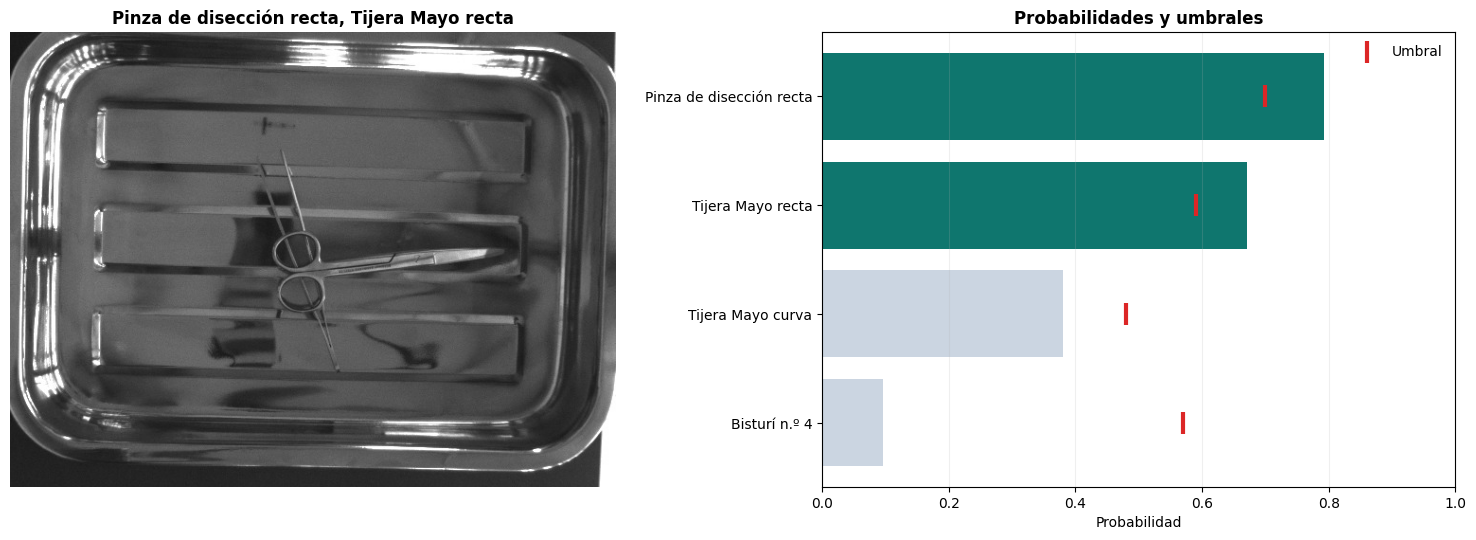

,Instrumento,Original,Flip horizontal,Recorte central,Probabilidad final,Umbral,Margen,Detectado,Acuerdo de vistas
0,Pinza de disección recta,74.12%,79.33%,28.12%,79.33%,0.70,+0.0933,True,67%
1,Tijera Mayo recta,43.13%,50.76%,67.11%,67.11%,0.59,+0.0811,True,33%
2,Tijera Mayo curva,14.33%,15.83%,38.08%,38.08%,0.48,-0.0992,False,0%
3,Bisturí n.º 4,6.11%,5.14%,9.66%,9.66%,0.57,-0.4734,False,0%


In [5]:
EXTENSIONES_VALIDAS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

if EN_COLAB:
    print("Selecciona una o varias imágenes para realizar la predicción.")
    archivos_imagen = files.upload()
    rutas_imagenes = [
        Path("/content") / nombre
        for nombre in archivos_imagen
        if Path(nombre).suffix.lower() in EXTENSIONES_VALIDAS
    ]
else:
    # Ejemplo local: rutas_imagenes = [Path("mi_imagen.jpg")]
    rutas_imagenes = []
    print("Modo local: agrega tus rutas a la lista rutas_imagenes y vuelve a ejecutar.")

if EN_COLAB and not rutas_imagenes:
    raise RuntimeError("No se seleccionó ninguna imagen válida.")

for ruta in rutas_imagenes:
    display(Markdown(f"### Resultado: `{ruta.name}`"))
    resultado = predecir_instrumentos(ruta, mostrar=True)

---

## 5. Prototipo del sistema inteligente (POC) — apartado 1.6

La POC se rediseñó con una apariencia más cercana a una aplicación comercial para un entorno de salud. La interfaz separa claramente la carga de la imagen, el estado del análisis, los resultados y la información técnica.

### Mejoras incorporadas

| Mejora | Implementación |
|---|---|
| Resultado sin detecciones | Mensaje visible: “No se encontraron instrumentos reconocidos” |
| Diseño profesional | Paleta clínica azul y verde, tarjetas, jerarquía visual y botones claros |
| Resumen ejecutivo | Número de instrumentos, mayor probabilidad y estado del análisis |
| Resultados interpretables | Etiquetas detectadas, probabilidad, umbral, margen y estabilidad |
| Manejo de errores | Mensajes comprensibles cuando falta una imagen o la entrada no es válida |
| Transparencia | Aviso permanente de que se trata de una POC académica |

> La interfaz no presenta el sistema como un dispositivo médico validado. Su finalidad es demostrar la integración funcional del modelo en una aplicación web.

In [6]:
import csv
import hashlib
import html
import json
import os
import re
import uuid
from datetime import datetime, timezone
from pathlib import Path

import gradio as gr


CLASES_RECONOCIBLES = list(
    globals().get(
        "CLASS_NAMES",
        [
            "Bisturí n.º 4",
            "Pinza de disección recta",
            "Tijera Mayo recta",
            "Tijera Mayo curva",
        ],
    )
)

ABREVIATURAS_CLASES = {
    "Bisturí n.º 4": "B4",
    "Pinza de disección recta": "PR",
    "Tijera Mayo recta": "MR",
    "Tijera Mayo curva": "MC",
}


def obtener_directorio_feedback() -> Path:
    """
    Define dónde se guardarán las imágenes y etiquetas validadas.

    Prioridad:
    1. Variable de entorno SURGIVISION_FEEDBACK_DIR.
    2. Google Drive montado en Colab.
    3. Carpeta local junto al entorno de ejecución.
    """

    ruta_configurada = os.getenv("SURGIVISION_FEEDBACK_DIR")
    if ruta_configurada:
        return Path(ruta_configurada).expanduser().resolve()

    drive = Path("/content/drive/MyDrive")
    if drive.exists():
        return drive / "SurgiVision_AI" / "feedback_entrenamiento"

    return Path.cwd() / "surgivision_feedback"


DIRECTORIO_FEEDBACK = obtener_directorio_feedback()
DIRECTORIO_IMAGENES = DIRECTORIO_FEEDBACK / "imagenes"
ARCHIVO_CSV = DIRECTORIO_FEEDBACK / "feedback_validado.csv"
ARCHIVO_JSONL = DIRECTORIO_FEEDBACK / "feedback_validado.jsonl"

DIRECTORIO_IMAGENES.mkdir(parents=True, exist_ok=True)

MODELO_VERSION = Path(
    str(
        globals().get(
            "RUTA_MODELO",
            globals().get("MODEL_PATH", "modelo_instrumentos_multilabel.h5"),
        )
    )
).name


CSS_CLINICO_V3 = """
:root {
    --navy-950: #071C33;
    --navy-900: #0B2447;
    --navy-800: #123B63;
    --blue-650: #0E6FA3;
    --blue-100: #E9F5FC;
    --teal-750: #0B6B63;
    --teal-100: #DFF7F2;
    --green-750: #067647;
    --green-100: #ECFDF3;
    --amber-750: #B54708;
    --amber-100: #FFF7E8;
    --red-750: #B42318;
    --red-100: #FFF1F0;
    --violet-750: #6941C6;
    --violet-100: #F4F0FF;
    --slate-950: #102A43;
    --slate-750: #486581;
    --slate-500: #829AB1;
    --slate-300: #D9E2EC;
    --slate-150: #E8EEF3;
    --slate-100: #F0F4F8;
    --surface: #FFFFFF;
    --background: #F3F7FA;
}

.gradio-container {
    max-width: 1420px !important;
    margin: 0 auto !important;
    padding-bottom: 30px !important;
    background:
        radial-gradient(circle at 0% 0%, rgba(14,111,163,.07), transparent 22%),
        var(--background) !important;
    font-family: Inter, ui-sans-serif, system-ui, -apple-system,
                 BlinkMacSystemFont, "Segoe UI", sans-serif !important;
}

#clinical-header {
    position: relative;
    overflow: hidden;
    background:
        radial-gradient(circle at 89% 8%, rgba(255,255,255,.20), transparent 23%),
        radial-gradient(circle at 72% 95%, rgba(87,221,201,.16), transparent 26%),
        linear-gradient(122deg, var(--navy-950) 0%, var(--blue-650) 62%, var(--teal-750) 100%);
    border-radius: 26px;
    padding: 31px 35px;
    margin: 8px 0 14px;
    color: white;
    box-shadow: 0 20px 48px rgba(7,28,51,.20);
}

.header-content {
    display: flex;
    align-items: center;
    justify-content: space-between;
    gap: 24px;
}

.brand-row {
    display: flex;
    align-items: center;
    gap: 17px;
}

.brand-mark {
    width: 64px;
    height: 64px;
    min-width: 64px;
    display: grid;
    place-items: center;
    border-radius: 19px;
    background: rgba(255,255,255,.15);
    border: 1px solid rgba(255,255,255,.30);
    box-shadow: inset 0 1px 0 rgba(255,255,255,.15);
    font-size: 22px;
    font-weight: 900;
    letter-spacing: -.7px;
}

.brand-title {
    margin: 0;
    color: white;
    font-size: 32px;
    line-height: 1.07;
    letter-spacing: -.65px;
}

.brand-subtitle {
    margin: 7px 0 0;
    color: rgba(255,255,255,.88);
    font-size: 15px;
}

.system-ready {
    display: inline-flex;
    align-items: center;
    gap: 9px;
    padding: 10px 14px;
    border-radius: 999px;
    background: rgba(255,255,255,.14);
    border: 1px solid rgba(255,255,255,.25);
    font-size: 12px;
    font-weight: 800;
    white-space: nowrap;
}

.ready-dot {
    width: 9px;
    height: 9px;
    border-radius: 50%;
    background: #6CE9A6;
    box-shadow: 0 0 0 4px rgba(108,233,166,.18);
}

.prototype-label {
    margin-top: 18px;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: .85px;
    color: rgba(255,255,255,.72);
}

.feature-strip {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 10px;
    margin: 0 0 15px;
}

.feature-card {
    display: flex;
    align-items: center;
    gap: 11px;
    padding: 12px 14px;
    background: rgba(255,255,255,.92);
    border: 1px solid var(--slate-300);
    border-radius: 15px;
    box-shadow: 0 6px 16px rgba(31,55,76,.05);
}

.feature-icon {
    width: 32px;
    height: 32px;
    min-width: 32px;
    display: grid;
    place-items: center;
    border-radius: 10px;
    background: var(--blue-100);
    color: var(--blue-650);
    font-size: 15px;
    font-weight: 900;
}

.feature-title {
    color: var(--slate-950);
    font-size: 12px;
    font-weight: 850;
}

.feature-copy {
    margin-top: 2px;
    color: var(--slate-750);
    font-size: 11px;
}

.medical-card {
    background: rgba(255,255,255,.97) !important;
    border: 1px solid var(--slate-300) !important;
    border-radius: 22px !important;
    padding: 21px !important;
    box-shadow: 0 10px 30px rgba(31,55,76,.075) !important;
}

.section-kicker {
    color: var(--teal-750);
    font-size: 11px;
    font-weight: 900;
    text-transform: uppercase;
    letter-spacing: 1.25px;
    margin-bottom: 4px;
}

.section-title {
    color: var(--navy-900);
    font-size: 22px;
    font-weight: 850;
    margin: 0 0 6px;
    letter-spacing: -.25px;
}

.section-copy {
    color: var(--slate-750);
    font-size: 14px;
    line-height: 1.5;
    margin-bottom: 14px;
}

.section-divider {
    height: 1px;
    background: linear-gradient(90deg, var(--slate-300), transparent);
    margin: 19px 0;
}

.class-grid {
    display: grid;
    grid-template-columns: repeat(2, minmax(0, 1fr));
    gap: 10px;
    margin: 12px 0 4px;
}

.class-card {
    display: flex;
    align-items: center;
    gap: 12px;
    min-height: 72px;
    padding: 13px 14px;
    border: 1px solid var(--slate-300);
    border-radius: 15px;
    background:
        linear-gradient(145deg, #FFFFFF 0%, #F8FCFD 100%);
    transition: transform .18s ease, box-shadow .18s ease, border-color .18s ease;
}

.class-card:hover {
    transform: translateY(-1px);
    border-color: #9CCFE4;
    box-shadow: 0 8px 18px rgba(14,111,163,.08);
}

.class-badge {
    width: 39px;
    height: 39px;
    min-width: 39px;
    display: grid;
    place-items: center;
    border-radius: 12px;
    background: var(--teal-100);
    color: var(--teal-750);
    font-weight: 900;
    font-size: 12px;
    letter-spacing: -.2px;
}

.class-name {
    color: var(--slate-950);
    font-size: 13px;
    font-weight: 800;
    line-height: 1.25;
}

.class-caption {
    margin-top: 4px;
    color: var(--slate-500);
    font-size: 11px;
}

.scope-note {
    margin-top: 11px;
    padding: 11px 13px;
    border-radius: 12px;
    background: var(--slate-100);
    color: var(--slate-750);
    font-size: 12px;
    line-height: 1.48;
}

.status-card {
    border-radius: 18px;
    padding: 20px 21px;
    border: 1px solid;
    margin-bottom: 13px;
    box-shadow: 0 6px 16px rgba(31,55,76,.035);
}

.status-success {
    background: linear-gradient(145deg, var(--green-100), #F7FFF9);
    border-color: #ABEFC6;
    color: var(--green-750);
}

.status-empty {
    background: linear-gradient(145deg, #F8FAFC, #FFFFFF);
    border-color: #CBD5E1;
    color: #334155;
}

.status-warning {
    background: linear-gradient(145deg, var(--amber-100), #FFFDF7);
    border-color: #FEDF89;
    color: var(--amber-750);
}

.status-error {
    background: linear-gradient(145deg, var(--red-100), #FFF8F7);
    border-color: #FECDCA;
    color: var(--red-750);
}

.status-idle {
    background: linear-gradient(145deg, #EFF6FF, #F8FBFF);
    border-color: #B2DDFF;
    color: #1849A9;
}

.status-heading {
    margin: 0 0 7px;
    font-size: 18px;
    font-weight: 900;
}

.status-copy {
    margin: 0;
    font-size: 14px;
    line-height: 1.55;
}

.result-instrument-grid {
    display: grid;
    grid-template-columns: repeat(2, minmax(0, 1fr));
    gap: 9px;
    margin-top: 13px;
}

.result-instrument-card {
    display: flex;
    align-items: center;
    gap: 10px;
    padding: 12px 13px;
    border-radius: 13px;
    background: white;
    border: 1px solid #ABEFC6;
    color: #05603A;
    font-size: 13px;
    font-weight: 820;
}

.result-check {
    width: 25px;
    height: 25px;
    min-width: 25px;
    display: grid;
    place-items: center;
    border-radius: 50%;
    background: #D1FADF;
    font-size: 13px;
    font-weight: 950;
}

.clinical-summary-grid {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 10px;
    margin: 0 0 12px;
}

.summary-card {
    min-height: 105px;
    padding: 14px;
    border: 1px solid var(--slate-300);
    border-radius: 15px;
    background: linear-gradient(155deg, white, #FBFDFE);
}

.summary-label {
    color: var(--slate-500);
    font-size: 11px;
    font-weight: 850;
    text-transform: uppercase;
    letter-spacing: .58px;
}

.summary-value {
    margin-top: 7px;
    color: var(--navy-900);
    font-size: 18px;
    font-weight: 900;
    line-height: 1.15;
}

.summary-note {
    margin-top: 5px;
    color: var(--slate-750);
    font-size: 11px;
    line-height: 1.38;
}

.context-strip {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 8px;
    padding: 12px 14px;
    border-radius: 13px;
    background: var(--slate-100);
    border: 1px solid var(--slate-300);
    color: var(--slate-750);
    font-size: 12px;
}

.context-strip b {
    color: var(--slate-950);
}

.feedback-shell {
    padding: 16px;
    border-radius: 17px;
    background:
        linear-gradient(145deg, rgba(244,240,255,.88), rgba(255,255,255,.96));
    border: 1px solid #D9D6FE;
    box-shadow: 0 7px 20px rgba(105,65,198,.055);
}

.feedback-heading-row {
    display: flex;
    align-items: center;
    justify-content: space-between;
    gap: 10px;
    margin-bottom: 8px;
}

.feedback-title {
    color: #42307D;
    font-size: 15px;
    font-weight: 900;
}

.feedback-badge {
    padding: 5px 9px;
    border-radius: 999px;
    background: var(--violet-100);
    color: var(--violet-750);
    border: 1px solid #D9D6FE;
    font-size: 10px;
    font-weight: 850;
    letter-spacing: .45px;
}

.feedback-copy {
    color: #594E72;
    font-size: 12px;
    line-height: 1.5;
    margin-bottom: 12px;
}

.verification-card {
    padding: 13px 14px;
    border-radius: 13px;
    background: #FFFFFF;
    border: 1px solid #D9D6FE;
    color: #594E72;
    font-size: 12px;
    line-height: 1.5;
}

.verification-success {
    background: var(--green-100);
    border-color: #ABEFC6;
    color: var(--green-750);
}

.verification-warning {
    background: var(--amber-100);
    border-color: #FEDF89;
    color: var(--amber-750);
}

.verification-error {
    background: var(--red-100);
    border-color: #FECDCA;
    color: var(--red-750);
}

.correction-panel {
    margin-top: 11px !important;
    padding: 13px !important;
    border-radius: 14px !important;
    background: rgba(255,255,255,.88) !important;
    border: 1px dashed #BDB4FE !important;
}

.capture-note,
.privacy-note {
    padding: 12px 14px;
    border-radius: 13px;
    font-size: 12px;
    line-height: 1.5;
}

.capture-note {
    margin-top: 12px;
    background: #F8FAFC;
    border: 1px solid var(--slate-300);
    color: var(--slate-750);
}

.privacy-note {
    margin-top: 9px;
    background: #F5F3FF;
    border: 1px solid #DDD6FE;
    color: #5B21B6;
}

.storage-note {
    padding: 12px 14px;
    border-radius: 13px;
    background: #F8FAFC;
    border: 1px solid var(--slate-300);
    color: var(--slate-750);
    font-size: 11px;
    line-height: 1.5;
}

#analyze-button,
#clear-button,
#confirm-save-button,
#open-correction-button,
#save-correction-button,
#export-button {
    min-height: 48px;
    border-radius: 12px !important;
    font-weight: 820 !important;
}

#analyze-button,
#confirm-save-button {
    box-shadow: 0 8px 20px rgba(14,111,163,.16);
}

.footer-disclaimer {
    margin-top: 17px;
    padding: 14px 16px;
    border-radius: 14px;
    background: #FFF7ED;
    border: 1px solid #FED7AA;
    color: #9A3412;
    font-size: 12px;
    line-height: 1.55;
}

@media (max-width: 920px) {
    .header-content {
        align-items: flex-start;
        flex-direction: column;
    }

    .feature-strip,
    .clinical-summary-grid {
        grid-template-columns: 1fr;
    }
}

@media (max-width: 720px) {
    #clinical-header {
        padding: 23px;
    }

    .brand-title {
        font-size: 25px;
    }

    .class-grid,
    .result-instrument-grid,
    .context-strip {
        grid-template-columns: 1fr;
    }
}
"""


def construir_clases_html():
    tarjetas = []
    for clase in CLASES_RECONOCIBLES:
        abreviatura = ABREVIATURAS_CLASES.get(clase, clase[:2].upper())
        tarjetas.append(
            f"""
            <div class="class-card">
                <div class="class-badge">{html.escape(abreviatura)}</div>
                <div>
                    <div class="class-name">{html.escape(str(clase))}</div>
                    <div class="class-caption">Clase disponible en el modelo</div>
                </div>
            </div>
            """
        )

    return f"""
    <div class="class-grid">{''.join(tarjetas)}</div>
    <div class="scope-note">
        El sistema reconoce únicamente las clases mostradas. Un instrumento
        diferente puede no ser identificado aunque esté presente en la imagen.
    </div>
    """


def construir_almacenamiento_html():
    if str(DIRECTORIO_FEEDBACK).startswith("/content/drive/MyDrive"):
        tipo = "Google Drive"
        detalle = "Los registros permanecerán disponibles después de cerrar Colab."
    else:
        tipo = "almacenamiento local"
        detalle = (
            "En Colab, monte Google Drive para conservar los registros "
            "después de finalizar la sesión."
        )

    return f"""
    <div class="storage-note">
        <b>Destino de validaciones:</b> {html.escape(tipo)}.<br>
        {html.escape(detalle)}
    </div>
    """


ENCABEZADO_HTML = """
<div id="clinical-header">
    <div class="header-content">
        <div class="brand-row">
            <div class="brand-mark">SV</div>
            <div>
                <h1 class="brand-title">SurgiVision AI</h1>
                <p class="brand-subtitle">
                    Asistente visual para reconocimiento de instrumental quirúrgico
                </p>
            </div>
        </div>
        <div class="system-ready">
            <span class="ready-dot"></span>
            Sistema disponible
        </div>
    </div>
    <div class="prototype-label">
        PROTOTIPO ACADÉMICO · APOYO VISUAL CON VALIDACIÓN HUMANA
    </div>
</div>
"""


CARACTERISTICAS_HTML = """
<div class="feature-strip">
    <div class="feature-card">
        <div class="feature-icon">4</div>
        <div>
            <div class="feature-title">Clases reconocibles</div>
            <div class="feature-copy">Instrumental incluido en el entrenamiento.</div>
        </div>
    </div>
    <div class="feature-card">
        <div class="feature-icon">✓</div>
        <div>
            <div class="feature-title">Validación humana</div>
            <div class="feature-copy">El profesional confirma o corrige el resultado.</div>
        </div>
    </div>
    <div class="feature-card">
        <div class="feature-icon">↻</div>
        <div>
            <div class="feature-title">Mejora continua</div>
            <div class="feature-copy">Las correcciones forman un conjunto para reentrenamiento.</div>
        </div>
    </div>
</div>
"""


ESTADO_INICIAL_HTML = """
<div class="status-card status-idle">
    <p class="status-heading">Preparado para iniciar</p>
    <p class="status-copy">
        Cargue o capture una imagen y seleccione <b>Analizar imagen</b>.
        El resultado deberá verificarse antes de guardarlo.
    </p>
</div>
"""


RESUMEN_INICIAL_HTML = """
<div class="clinical-summary-grid">
    <div class="summary-card">
        <div class="summary-label">Resultado</div>
        <div class="summary-value">Pendiente</div>
        <div class="summary-note">Aún no se ha ejecutado el análisis.</div>
    </div>
    <div class="summary-card">
        <div class="summary-label">Imagen</div>
        <div class="summary-value">Sin analizar</div>
        <div class="summary-note">Cargue una fotografía para continuar.</div>
    </div>
    <div class="summary-card">
        <div class="summary-label">Validación</div>
        <div class="summary-value">Pendiente</div>
        <div class="summary-note">El resultado todavía no ha sido guardado.</div>
    </div>
</div>
"""


VALIDACION_INICIAL_HTML = """
<div class="verification-card">
    Tras analizar la imagen, puede <b>confirmar y guardar</b> la predicción
    o abrir la corrección para seleccionar las etiquetas observadas.
</div>
"""


def construir_estado_clinico(resultado):
    estado_tecnico = str(resultado.get("estado", "")).upper()
    mensaje = html.escape(str(resultado.get("mensaje", "")))

    if estado_tecnico == "IMAGEN_NO_APTA":
        return f"""
        <div class="status-card status-warning">
            <p class="status-heading">La imagen debe repetirse</p>
            <p class="status-copy">
                {mensaje or "La fotografía no reúne las condiciones necesarias para el análisis."}
            </p>
        </div>
        """

    instrumentos = [
        str(nombre)
        for nombre in resultado.get("instrumentos_detectados", [])
    ]
    hay_detecciones = bool(
        resultado.get("hay_detecciones", instrumentos)
    )

    if hay_detecciones and instrumentos:
        tarjetas = "".join(
            f"""
            <div class="result-instrument-card">
                <span class="result-check">✓</span>
                <span>{html.escape(nombre)}</span>
            </div>
            """
            for nombre in instrumentos
        )

        cantidad = len(instrumentos)
        texto = (
            "Se reconoció 1 tipo de instrumento."
            if cantidad == 1
            else f"Se reconocieron {cantidad} tipos de instrumentos."
        )

        return f"""
        <div class="status-card status-success">
            <p class="status-heading">Instrumentos reconocidos</p>
            <p class="status-copy">
                {texto} Compruebe visualmente la identificación antes de
                incorporarla al conjunto de validación.
            </p>
            <div class="result-instrument-grid">{tarjetas}</div>
        </div>
        """

    return """
    <div class="status-card status-empty">
        <p class="status-heading">No se reconocieron instrumentos</p>
        <p class="status-copy">
            Ninguna de las cuatro clases disponibles fue identificada.
            Confirme este resultado o seleccione las clases correctas cuando
            el modelo haya omitido algún instrumento.
        </p>
    </div>
    """


def construir_resumen_clinico(resultado, codigo_control, momento_control):
    instrumentos = [
        str(nombre)
        for nombre in resultado.get("instrumentos_detectados", [])
    ]
    cantidad = len(instrumentos)
    estado_tecnico = str(resultado.get("estado", "")).upper()

    if estado_tecnico == "IMAGEN_NO_APTA":
        resultado_texto = "Repetir captura"
        resultado_nota = "La imagen no fue considerada apta."
        imagen_texto = "No procesada"
        imagen_nota = "Capture una nueva fotografía."
    elif cantidad == 0:
        resultado_texto = "Sin reconocimiento"
        resultado_nota = "Ninguna clase disponible fue identificada."
        imagen_texto = "Analizada"
        imagen_nota = "El modelo completó el procesamiento."
    elif cantidad == 1:
        resultado_texto = "1 tipo reconocido"
        resultado_nota = instrumentos[0]
        imagen_texto = "Analizada"
        imagen_nota = "El modelo completó el procesamiento."
    else:
        resultado_texto = f"{cantidad} tipos reconocidos"
        resultado_nota = "Resultado multilabel."
        imagen_texto = "Analizada"
        imagen_nota = "El modelo completó el procesamiento."

    codigo = html.escape(
        str(codigo_control).strip()
        if codigo_control and str(codigo_control).strip()
        else "No registrado"
    )
    momento = html.escape(
        str(momento_control)
        if momento_control
        else "No especificado"
    )

    return f"""
    <div class="clinical-summary-grid">
        <div class="summary-card">
            <div class="summary-label">Resultado</div>
            <div class="summary-value">{html.escape(resultado_texto)}</div>
            <div class="summary-note">{html.escape(resultado_nota)}</div>
        </div>
        <div class="summary-card">
            <div class="summary-label">Imagen</div>
            <div class="summary-value">{imagen_texto}</div>
            <div class="summary-note">{imagen_nota}</div>
        </div>
        <div class="summary-card">
            <div class="summary-label">Validación</div>
            <div class="summary-value">Pendiente</div>
            <div class="summary-note">Confirme o corrija las etiquetas.</div>
        </div>
    </div>
    <div class="context-strip">
        <div><b>Código de control:</b> {codigo}</div>
        <div><b>Momento:</b> {momento}</div>
    </div>
    """


def extraer_probabilidades(resultado):
    tabla = resultado.get("tabla")
    if tabla is None:
        return {}

    try:
        return {
            str(fila["Instrumento"]): float(fila["Probabilidad final"])
            for _, fila in tabla.iterrows()
        }
    except Exception:
        return {}


def predecir_interfaz(imagen, codigo_control, momento_control):
    if imagen is None:
        return (
            """
            <div class="status-card status-warning">
                <p class="status-heading">No se ha cargado una imagen</p>
                <p class="status-copy">
                    Capture o seleccione una fotografía antes de iniciar el análisis.
                </p>
            </div>
            """,
            RESUMEN_INICIAL_HTML,
            VALIDACION_INICIAL_HTML,
            None,
            gr.update(visible=False),
            [],
        )

    try:
        resultado = predecir_instrumentos(imagen)
        instrumentos = [
            str(nombre)
            for nombre in resultado.get("instrumentos_detectados", [])
        ]

        registro_interfaz = {
            "analizado": True,
            "feedback_guardado": False,
            "estado": str(resultado.get("estado", "")),
            "predicciones": instrumentos,
            "probabilidades": extraer_probabilidades(resultado),
            "imagen": resultado.get("imagen", imagen),
            "codigo_control": (
                str(codigo_control).strip()
                if codigo_control and str(codigo_control).strip()
                else ""
            ),
            "momento_control": str(momento_control or ""),
            "modelo_version": MODELO_VERSION,
            "fecha_analisis_utc": datetime.now(timezone.utc).isoformat(),
        }

        return (
            construir_estado_clinico(resultado),
            construir_resumen_clinico(
                resultado,
                codigo_control,
                momento_control,
            ),
            VALIDACION_INICIAL_HTML,
            registro_interfaz,
            gr.update(visible=False),
            instrumentos,
        )

    except Exception as error:
        print(f"[SurgiVision AI] Error durante el análisis: {error}")

        return (
            """
            <div class="status-card status-error">
                <p class="status-heading">No fue posible completar el análisis</p>
                <p class="status-copy">
                    Revise la imagen e inténtelo nuevamente. Si el problema
                    continúa, comuníquelo al responsable técnico.
                </p>
            </div>
            """,
            RESUMEN_INICIAL_HTML,
            VALIDACION_INICIAL_HTML,
            None,
            gr.update(visible=False),
            [],
        )


def al_cambiar_imagen(imagen):
    if imagen is None:
        return (
            ESTADO_INICIAL_HTML,
            RESUMEN_INICIAL_HTML,
            VALIDACION_INICIAL_HTML,
            None,
            gr.update(visible=False),
            [],
        )

    return (
        """
        <div class="status-card status-idle">
            <p class="status-heading">Imagen preparada</p>
            <p class="status-copy">
                La fotografía fue cargada. Seleccione <b>Analizar imagen</b>
                para obtener el resultado.
            </p>
        </div>
        """,
        RESUMEN_INICIAL_HTML,
        VALIDACION_INICIAL_HTML,
        None,
        gr.update(visible=False),
        [],
    )


def sanitizar_fragmento(texto):
    valor = re.sub(r"[^A-Za-z0-9_-]+", "_", str(texto or "").strip())
    return valor.strip("_")[:36] or "sin_codigo"


def calcular_hash_archivo(ruta):
    digest = hashlib.sha256()
    with open(ruta, "rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            digest.update(bloque)
    return digest.hexdigest()


def contar_registros():
    if not ARCHIVO_CSV.exists():
        return 0

    with ARCHIVO_CSV.open("r", encoding="utf-8-sig", newline="") as archivo:
        return max(sum(1 for _ in archivo) - 1, 0)


def guardar_fila_csv(registro):
    campos = [
        "id_registro",
        "fecha_validacion_utc",
        "archivo_imagen",
        "sha256_imagen",
        "codigo_control",
        "momento_control",
        "modelo_version",
        "estado_modelo",
        "etiquetas_predichas",
        "etiquetas_validadas",
        "vector_etiquetas",
        "tipo_feedback",
        "probabilidades",
        "observaciones",
    ]

    existe = ARCHIVO_CSV.exists()
    fila = dict(registro)
    for campo in (
        "etiquetas_predichas",
        "etiquetas_validadas",
        "vector_etiquetas",
        "probabilidades",
    ):
        fila[campo] = json.dumps(
            fila[campo],
            ensure_ascii=False,
            separators=(",", ":"),
        )

    with ARCHIVO_CSV.open(
        "a",
        encoding="utf-8-sig",
        newline="",
    ) as archivo:
        escritor = csv.DictWriter(archivo, fieldnames=campos)
        if not existe:
            escritor.writeheader()
        escritor.writerow({campo: fila.get(campo, "") for campo in campos})


def guardar_fila_jsonl(registro):
    with ARCHIVO_JSONL.open("a", encoding="utf-8") as archivo:
        archivo.write(
            json.dumps(registro, ensure_ascii=False) + "\n"
        )


def guardar_validacion(
    registro_interfaz,
    etiquetas_validadas,
    observaciones,
    origen_accion,
):
    if not registro_interfaz or not registro_interfaz.get("analizado"):
        return (
            """
            <div class="verification-card verification-warning">
                Primero debe analizar una imagen.
            </div>
            """,
            registro_interfaz,
            gr.update(visible=False),
        )

    if registro_interfaz.get("feedback_guardado"):
        return (
            """
            <div class="verification-card verification-warning">
                Esta imagen ya fue guardada. Inicie un nuevo análisis para
                evitar registros duplicados.
            </div>
            """,
            registro_interfaz,
            gr.update(visible=False),
        )

    if str(registro_interfaz.get("estado", "")).upper() == "IMAGEN_NO_APTA":
        return (
            """
            <div class="verification-card verification-warning">
                Una imagen no apta no se guarda como etiqueta de entrenamiento.
                Repita la captura antes de validarla.
            </div>
            """,
            registro_interfaz,
            gr.update(visible=False),
        )

    predichas = [
        clase
        for clase in registro_interfaz.get("predicciones", [])
        if clase in CLASES_RECONOCIBLES
    ]
    validadas = [
        clase
        for clase in (etiquetas_validadas or [])
        if clase in CLASES_RECONOCIBLES
    ]

    if origen_accion == "confirmacion":
        validadas = predichas

    tipo_feedback = (
        "confirmacion"
        if set(validadas) == set(predichas)
        else "correccion"
    )

    imagen = registro_interfaz.get("imagen")
    if imagen is None:
        return (
            """
            <div class="verification-card verification-error">
                No se encontró la imagen asociada al análisis.
            </div>
            """,
            registro_interfaz,
            gr.update(visible=False),
        )

    DIRECTORIO_IMAGENES.mkdir(parents=True, exist_ok=True)

    fecha = datetime.now(timezone.utc)
    identificador = uuid.uuid4().hex
    codigo_archivo = sanitizar_fragmento(
        registro_interfaz.get("codigo_control", "")
    )
    nombre_imagen = (
        f"{fecha.strftime('%Y%m%dT%H%M%SZ')}_"
        f"{codigo_archivo}_{identificador[:10]}.jpg"
    )
    ruta_imagen = DIRECTORIO_IMAGENES / nombre_imagen

    imagen.convert("RGB").save(
        ruta_imagen,
        format="JPEG",
        quality=95,
        optimize=True,
    )

    vector = [
        int(clase in validadas)
        for clase in CLASES_RECONOCIBLES
    ]

    registro = {
        "id_registro": identificador,
        "fecha_validacion_utc": fecha.isoformat(),
        "archivo_imagen": str(ruta_imagen),
        "sha256_imagen": calcular_hash_archivo(ruta_imagen),
        "codigo_control": registro_interfaz.get("codigo_control", ""),
        "momento_control": registro_interfaz.get("momento_control", ""),
        "modelo_version": registro_interfaz.get(
            "modelo_version",
            MODELO_VERSION,
        ),
        "estado_modelo": registro_interfaz.get("estado", ""),
        "etiquetas_predichas": predichas,
        "etiquetas_validadas": validadas,
        "vector_etiquetas": vector,
        "tipo_feedback": tipo_feedback,
        "probabilidades": registro_interfaz.get("probabilidades", {}),
        "observaciones": str(observaciones or "").strip(),
    }

    guardar_fila_csv(registro)
    guardar_fila_jsonl(registro)

    actualizado = dict(registro_interfaz)
    actualizado["feedback_guardado"] = True
    actualizado["id_feedback"] = identificador
    actualizado["etiquetas_validadas"] = validadas

    total = contar_registros()
    if tipo_feedback == "confirmacion":
        encabezado = "Validación guardada"
        detalle = (
            "La predicción fue confirmada y se incorporó al conjunto "
            "de datos validados."
        )
    else:
        encabezado = "Corrección guardada"
        detalle = (
            "Las etiquetas corregidas se incorporaron al conjunto "
            "de datos para mejora del modelo."
        )

    return (
        f"""
        <div class="verification-card verification-success">
            <b>{encabezado}.</b> {detalle}<br>
            Registro acumulado: <b>{total}</b> imágenes validadas.
        </div>
        """,
        actualizado,
        gr.update(visible=False),
    )


def confirmar_y_guardar(registro_interfaz, observaciones):
    predichas = (
        registro_interfaz.get("predicciones", [])
        if registro_interfaz
        else []
    )
    return guardar_validacion(
        registro_interfaz,
        predichas,
        observaciones,
        "confirmacion",
    )


def abrir_correccion(registro_interfaz):
    if not registro_interfaz or not registro_interfaz.get("analizado"):
        return (
            gr.update(visible=False),
            [],
            """
            <div class="verification-card verification-warning">
                Primero debe analizar una imagen.
            </div>
            """,
        )

    if registro_interfaz.get("feedback_guardado"):
        return (
            gr.update(visible=False),
            registro_interfaz.get("predicciones", []),
            """
            <div class="verification-card verification-warning">
                Esta validación ya fue guardada. Inicie un nuevo análisis
                para registrar otra revisión.
            </div>
            """,
        )

    return (
        gr.update(visible=True),
        registro_interfaz.get("predicciones", []),
        """
        <div class="verification-card">
            Seleccione todas las clases que realmente aparecen en la imagen.
            Deje la selección vacía cuando no exista ninguno de los cuatro
            instrumentos reconocibles.
        </div>
        """,
    )


def guardar_correccion(
    registro_interfaz,
    etiquetas_corregidas,
    observaciones,
):
    return guardar_validacion(
        registro_interfaz,
        etiquetas_corregidas,
        observaciones,
        "correccion",
    )


def preparar_exportacion():
    if not ARCHIVO_CSV.exists():
        raise gr.Error(
            "Todavía no existen validaciones guardadas para exportar."
        )
    return str(ARCHIVO_CSV)


def limpiar_interfaz():
    return (
        None,
        "",
        "Antes del procedimiento",
        ESTADO_INICIAL_HTML,
        RESUMEN_INICIAL_HTML,
        VALIDACION_INICIAL_HTML,
        None,
        "",
        gr.update(visible=False),
        [],
    )


tema_clinico = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="teal",
    neutral_hue="slate",
    radius_size="lg",
    font=[
        gr.themes.GoogleFont("Inter"),
        "ui-sans-serif",
        "system-ui",
        "sans-serif",
    ],
)


with gr.Blocks(
    title="SurgiVision AI",
    theme=tema_clinico,
    css=CSS_CLINICO_V3,
) as demo:

    registro_ultimo_analisis = gr.State(None)

    gr.HTML(ENCABEZADO_HTML)
    gr.HTML(CARACTERISTICAS_HTML)

    with gr.Row(equal_height=False):

        with gr.Column(
            scale=5,
            elem_classes=["medical-card"],
        ):
            gr.HTML(
                """
                <div class="section-kicker">Captura</div>
                <div class="section-title">Registrar imagen</div>
                <div class="section-copy">
                    Tome una fotografía centrada, con iluminación uniforme
                    y con los instrumentos completamente visibles.
                </div>
                """
            )

            with gr.Row():
                codigo_control = gr.Textbox(
                    label="Código de bandeja o procedimiento (opcional)",
                    placeholder="Ej.: BAN-024",
                    max_lines=1,
                )

                momento_control = gr.Dropdown(
                    choices=[
                        "Antes del procedimiento",
                        "Durante el procedimiento",
                        "Después del procedimiento",
                        "Control de bandeja",
                        "Demostración académica",
                    ],
                    value="Antes del procedimiento",
                    label="Momento del control",
                )

            imagen_entrada = gr.Image(
                type="pil",
                image_mode="RGB",
                sources=["upload", "webcam", "clipboard"],
                label="Imagen para análisis",
                height=390,
            )

            with gr.Row():
                boton_analizar = gr.Button(
                    "Analizar imagen",
                    variant="primary",
                    elem_id="analyze-button",
                )
                boton_limpiar = gr.Button(
                    "Nuevo análisis",
                    variant="secondary",
                    elem_id="clear-button",
                )

            gr.HTML(
                """
                <div class="capture-note">
                    <b>Captura recomendada:</b> separe los instrumentos,
                    evite reflejos intensos, fondos metálicos y superposiciones
                    que oculten su forma.
                </div>
                <div class="privacy-note">
                    <b>Privacidad:</b> no incluya nombres, rostros, etiquetas
                    ni otros datos identificables del paciente.
                </div>
                """
            )

        with gr.Column(
            scale=7,
            elem_classes=["medical-card"],
        ):
            gr.HTML(
                """
                <div class="section-kicker">Capacidades</div>
                <div class="section-title">Instrumentos reconocibles</div>
                <div class="section-copy">
                    La versión actual del sistema está limitada a las siguientes
                    cuatro clases.
                </div>
                """
            )

            gr.HTML(construir_clases_html())
            gr.HTML('<div class="section-divider"></div>')

            gr.HTML(
                """
                <div class="section-kicker">Resultado</div>
                <div class="section-title">Revisión del análisis</div>
                <div class="section-copy">
                    La identificación es preliminar y debe validarse mediante
                    inspección visual.
                </div>
                """
            )

            estado_salida = gr.HTML(ESTADO_INICIAL_HTML)
            resumen_salida = gr.HTML(RESUMEN_INICIAL_HTML)

            gr.HTML('<div class="section-divider"></div>')

            with gr.Column(elem_classes=["feedback-shell"]):
                gr.HTML(
                    """
                    <div class="feedback-heading-row">
                        <div class="feedback-title">
                            Validación para mejora del modelo
                        </div>
                        <div class="feedback-badge">HUMANO EN EL CICLO</div>
                    </div>
                    <div class="feedback-copy">
                        La confirmación o corrección guarda la imagen junto con
                        sus etiquetas validadas. Estos registros pueden utilizarse
                        después para entrenar nuevas versiones del modelo.
                    </div>
                    """
                )

                validacion_salida = gr.HTML(VALIDACION_INICIAL_HTML)

                observaciones = gr.Textbox(
                    label="Observaciones de la validación (opcional)",
                    placeholder=(
                        "Ej.: reflejo intenso, instrumento parcialmente cubierto..."
                    ),
                    lines=2,
                )

                with gr.Row():
                    boton_confirmar_guardar = gr.Button(
                        "✓ Confirmar y guardar",
                        variant="primary",
                        elem_id="confirm-save-button",
                    )
                    boton_abrir_correccion = gr.Button(
                        "✎ Corregir resultado",
                        variant="secondary",
                        elem_id="open-correction-button",
                    )

                with gr.Column(
                    visible=False,
                    elem_classes=["correction-panel"],
                ) as panel_correccion:
                    etiquetas_corregidas = gr.CheckboxGroup(
                        choices=CLASES_RECONOCIBLES,
                        label="Instrumentos observados por el profesional",
                        info=(
                            "Seleccione todas las clases presentes. "
                            "Una selección vacía representa ningún instrumento."
                        ),
                    )
                    boton_guardar_correccion = gr.Button(
                        "Guardar corrección",
                        variant="primary",
                        elem_id="save-correction-button",
                    )

    with gr.Accordion(
        "Gestión del conjunto de validación",
        open=False,
    ):
        gr.HTML(construir_almacenamiento_html())
        with gr.Row():
            boton_exportar = gr.Button(
                "Preparar registro CSV",
                elem_id="export-button",
            )
            archivo_exportado = gr.File(
                label="Archivo de validaciones",
                interactive=False,
            )

    gr.HTML(
        """
        <div class="footer-disclaimer">
            <b>Aviso de uso:</b> SurgiVision AI es una prueba de concepto
            académica. No constituye un dispositivo médico, no reemplaza el
            conteo manual protocolizado ni la verificación establecida por el
            establecimiento de salud y no debe utilizarse para tomar decisiones
            clínicas.
        </div>
        """
    )

    boton_analizar.click(
        fn=predecir_interfaz,
        inputs=[
            imagen_entrada,
            codigo_control,
            momento_control,
        ],
        outputs=[
            estado_salida,
            resumen_salida,
            validacion_salida,
            registro_ultimo_analisis,
            panel_correccion,
            etiquetas_corregidas,
        ],
    )

    imagen_entrada.change(
        fn=al_cambiar_imagen,
        inputs=imagen_entrada,
        outputs=[
            estado_salida,
            resumen_salida,
            validacion_salida,
            registro_ultimo_analisis,
            panel_correccion,
            etiquetas_corregidas,
        ],
    )

    boton_confirmar_guardar.click(
        fn=confirmar_y_guardar,
        inputs=[
            registro_ultimo_analisis,
            observaciones,
        ],
        outputs=[
            validacion_salida,
            registro_ultimo_analisis,
            panel_correccion,
        ],
    )

    boton_abrir_correccion.click(
        fn=abrir_correccion,
        inputs=registro_ultimo_analisis,
        outputs=[
            panel_correccion,
            etiquetas_corregidas,
            validacion_salida,
        ],
    )

    boton_guardar_correccion.click(
        fn=guardar_correccion,
        inputs=[
            registro_ultimo_analisis,
            etiquetas_corregidas,
            observaciones,
        ],
        outputs=[
            validacion_salida,
            registro_ultimo_analisis,
            panel_correccion,
        ],
    )

    boton_exportar.click(
        fn=preparar_exportacion,
        inputs=[],
        outputs=archivo_exportado,
    )

    boton_limpiar.click(
        fn=limpiar_interfaz,
        inputs=[],
        outputs=[
            imagen_entrada,
            codigo_control,
            momento_control,
            estado_salida,
            resumen_salida,
            validacion_salida,
            registro_ultimo_analisis,
            observaciones,
            panel_correccion,
            etiquetas_corregidas,
        ],
    )


demo.launch(
    share=EN_COLAB,
    debug=False,
)

/tmp/ipykernel_1226/570129385.py:1347: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_1226/570129385.py:1347: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://979e429e1407f01db3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

## 6. Conclusiones

1. Se implementó una función propia de inferencia que integra la carga de imágenes, su conversión a RGB, el redimensionamiento a `224 × 224`, la generación de tres vistas y la aplicación de umbrales específicos por clase. La función devuelve resultados interpretables y permite reconocer simultáneamente varios instrumentos.

2. La función distingue explícitamente entre los estados `DETECCION` y `SIN_DETECCIONES`. Cuando ninguna clase supera su umbral, el sistema no fuerza una etiqueta y comunica al usuario que no se encontraron instrumentos reconocidos dentro de los umbrales configurados.

3. La salida sigmoide de cuatro neuronas es coherente con la naturaleza multilabel del problema, porque la presencia de un instrumento no excluye la presencia de los demás. La decisión final se realiza de forma independiente para cada clase.

4. La inferencia multivista permite comprobar la estabilidad de la predicción frente a una reflexión horizontal y un recorte central. El máximo por clase favorece la sensibilidad del prototipo, mientras que el porcentaje de acuerdo ayuda a identificar predicciones menos consistentes.

5. La interfaz web fue rediseñada con una estructura más cercana a una aplicación comercial: carga guiada de imágenes, estado visible del análisis, tarjetas de resumen, tabla simplificada y visualización técnica desplegable. Esto facilita el uso del modelo por una persona que no necesita editar código.

6. El prototipo está limitado a las cuatro clases utilizadas durante el entrenamiento y realiza clasificación de la imagen completa; no localiza cada instrumento mediante cajas delimitadoras. Su desempeño puede disminuir ante fondos, iluminación, escalas, oclusiones o instrumentos diferentes a los observados en el conjunto de datos.

7. Antes de una utilización real se requiere validación externa con imágenes independientes, análisis de errores por clase, control de versiones del modelo y evaluación bajo condiciones representativas del entorno de uso. Esta POC es académica y no constituye un dispositivo médico.

### Limitaciones principales

- Solo reconoce las cuatro clases incluidas durante el entrenamiento.
- Clasifica la imagen completa y no determina la ubicación espacial de cada instrumento.
- Puede verse afectado por cambios de iluminación, fondo, orientación u oclusión.
- Una ausencia de detección no confirma que la imagen esté libre de instrumental; únicamente indica que ninguna clase superó el umbral configurado.
- Requiere validación externa antes de considerar una aplicación real.

---

## 7. Referencias en formato APA 7

Abadi, M., Barham, P., Chen, J., Chen, Z., Davis, A., Dean, J., Devin, M., Ghemawat, S., Irving, G., Isard, M., Kudlur, M., Levenberg, J., Monga, R., Moore, S., Murray, D. G., Steiner, B., Tucker, P., Vasudevan, V., Warden, P., ... Zheng, X. (2016). TensorFlow: A system for large-scale machine learning. En *12th USENIX Symposium on Operating Systems Design and Implementation (OSDI 16)* (pp. 265–283). USENIX Association. https://www.usenix.org/conference/osdi16/technical-sessions/presentation/abadi

Gradio Team. (s. f.). *Gradio documentation*. Recuperado el 15 de julio de 2026, de https://www.gradio.app/docs

Keras Team. (s. f.). *Keras 3 API documentation*. Recuperado el 15 de julio de 2026, de https://keras.io/api/

Lavado, D., da Silva, J., & Caramelo, F. (2018). *Labeled surgical tools and images* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/dilavado/labeled-surgical-tools

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432

Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.-C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. En *2018 IEEE/CVF Conference on Computer Vision and Pattern Recognition* (pp. 4510–4520). IEEE. https://doi.org/10.1109/CVPR.2018.00474